#### Building Chatbot With multiple tools using langgraph

##### AIM:
 Create  chatbot with tool capabilities from arxiv, wikipedia search, Tavily(internet search) and some functions

In [18]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [19]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [20]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [21]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [22]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [23]:
from dotenv import load_dotenv
load_dotenv

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [24]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [25]:
tavily.invoke("Provide me the recent AI news")

[{'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Date: January 29, 2026\n\nSummary: Amazon has announced a fresh wave of layoffs impacting approximately 16,000 corporate employees, citing a strategic shift toward AI-driven automation and "agentic" workflows. The job cuts primarily target middle management and administrative roles that have become redundant as the company integrates more sophisticated AI systems to handle logistics planning, vendor relations, and internal reporting. While Amazon continues to hire for AI-specialized engineering roles, the move reflects a broader industry trend of "re-skilling" and restructuring as tech giants prioritize high-efficiency AI infrastructure over traditional staffing models. The company stated these cuts are necessary to remain agile in a rapidly evolving, AI-first retail landscape. [...] Date: January 14, 2026\n\nSummary: AstraZe

In [26]:
### Combine all the tools in the list

tools = [arxiv, wiki, tavily]

In [27]:
## Initialize my LLM Model

from langchain_groq import ChatGroq
llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [28]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent AI news. I need to figure out which tool to use here. Let me check the available tools.\n\nFirst, there\'s the arxiv function, which is for scientific papers in fields like physics and computer science. But the user is asking for news, not academic papers. Maybe not the best fit.\n\nNext, Wikipedia. That\'s for general knowledge and historical information. While AI topics might be covered there, it might not have the latest news. Wikipedia updates can be slow for current events.\n\nThen there\'s tavily_search_results_json. The description says it\'s optimized for current events with comprehensive and trusted results. That sounds perfect for recent AI news. The user probably wants up-to-date information on the latest developments, so using this search engine makes sense. \n\nI should call tavily_search_results_json with the query "recent AI News". That should fetch the latest articles and 

In [29]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': '3bangs6n2',
  'type': 'tool_call'}]

In [30]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

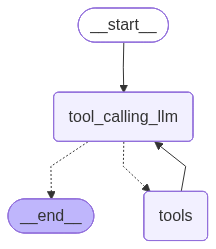

In [35]:
## Entire Chatbot With LangGraph

# from typing import TypedDict, Annotated
# from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from langchain_core.tools import tool
# from langchain_core.messages import AnyMessage

## Node Definition
def tool_calling_llm(state:State):
    """based on question call related tools"""
    messages: Annotated[list[AnyMessage], add_messages]

#Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tool condition routes to tools
    # If the latest message (result) from assistant is a not tool call -> tool condition routes to END
    tools_condition)
builder.add_edge("tools", "tool_calling_llm")  

graph = builder.compile()

#View
display(Image(graph.get_graph().draw_mermaid_png()))


In [36]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

1706.03762


In [37]:
messages = graph.invoke({"messages": HumanMessage(content="provide me recent top 10 ai news")})
for m in messages['messages']:
    m.pretty_print()


================================ Human Message =================================

provide me recent top 10 ai news


In [38]:
## invocation

messages=graph.invoke({"messages":"provide me recent top 10 ai news"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

provide me recent top 10 ai news
